# Exercise 7
## Action Recognition on KTH-Actions with Vision Transformers

## Imports

In [1]:
import copy
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

## Config

In [2]:
DATA_ROOT   = Path("/home/nfs/data/hdd_datasets/kth_actions")
NUM_FRAMES  = 10
BATCH_SIZE  = 32
NUM_WORKERS = 4
NUM_EPOCHS  = 15
LR          = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch._dynamo.reset()

Using device: cuda


## KTH Dataset

Same dataset and split as in Exercise 3 (Assignment 3):
- **Train**: persons 1–16
- **Valid**: persons 17–20
- **Test**: persons 21–25

Each video is split into non-overlapping subsequences of NUM_FRAMES frames.

In [3]:
class KTHDataset(Dataset):
    """ KTH Actions dataset; splits videos into fixed-length subsequences, split by person ID. """

    CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
    CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

    SPLIT_PERSONS = {
        "train": list(range(1, 17)),
        "valid": list(range(17, 21)),
        "test":  list(range(21, 26)),
    }

    def __init__(self, root, split="train", num_frames=10, stride=None, transform=None, preload=True):
        assert split in self.SPLIT_PERSONS
        self.num_frames = num_frames
        self.transform  = transform
        persons         = self.SPLIT_PERSONS[split]
        stride          = stride if stride is not None else num_frames   # default: non-overlapping

        processed_root = Path(root) / "processed"
        self.samples = []   # (sorted_frame_paths, start_idx, label)

        for cls in self.CLASSES:
            for video_dir in sorted((processed_root / cls).iterdir()):
                if not video_dir.is_dir():
                    continue
                stem = video_dir.name.split("_")[0].replace("person", "")
                if not stem.isdigit():
                    continue
                person_id = int(stem)
                if person_id not in persons:
                    continue
                frame_paths = sorted(video_dir.glob("*.png"))
                n = len(frame_paths)
                if n < num_frames:
                    continue
                label = self.CLASS_TO_IDX[cls]
                for start in range(0, n - num_frames + 1, stride):
                    self.samples.append((frame_paths, start, label))

        print(f"[{split:>5}] {len(self.samples)} subsequences from {len(persons)} persons  (stride={stride})")

        # pre-load all unique frames into RAM to avoid repeated disk reads
        self.cache = {}
        if preload:
            all_paths = set(
                path for frame_paths, start, _ in self.samples
                for path in frame_paths
            )
            print(f"[{split:>5}] preloading {len(all_paths)} frames into RAM...", end=" ", flush=True)
            for path in all_paths:
                img = Image.open(path).convert("L")
                self.cache[path] = np.array(img, dtype=np.float32) / 255.0
            print("done")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, start, label = self.samples[idx]
        frames = []
        for path in frame_paths[start : start + self.num_frames]:
            arr = self.cache[path] if path in self.cache else \
                  np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
            frames.append(arr)
        frames = np.stack(frames, axis=0)                   # (T, H, W)
        frames = torch.from_numpy(frames).unsqueeze(1)      # (T, 1, H, W)
        if self.transform:
            frames = self.transform(frames)   # one transform sampled for the whole clip
        return frames, label

## Create Datasets

In [4]:
class RandomHorizontalFlip:
    """ Applies the same random flip decision to every frame in a clip. """
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, x):
        # x: (T, C, H, W) -- one flip decision for the whole clip
        if torch.rand(1).item() < self.p:
            return torch.flip(x, dims=[-1])
        return x


class RandomAffine:
    """ Random rotation + translation via grid_sample, shared across all frames in a clip. """
    def __init__(self, degrees=10, translate=(0.05, 0.05)):
        self.degrees   = degrees
        self.translate = translate
    def __call__(self, x):
        # x: (T, C, H, W) -- one (angle, tx, ty) sampled for the whole clip
        T = x.shape[0]
        angle = (torch.rand(1).item() * 2 - 1) * self.degrees
        tx    = (torch.rand(1).item() * 2 - 1) * self.translate[0]
        ty    = (torch.rand(1).item() * 2 - 1) * self.translate[1]
        rad   = torch.tensor(angle * 3.14159 / 180.0)
        cos_a, sin_a = torch.cos(rad).item(), torch.sin(rad).item()
        theta = torch.tensor([[cos_a, -sin_a, tx],
                              [sin_a,  cos_a, ty]], dtype=torch.float32)
        theta = theta.unsqueeze(0).repeat(T, 1, 1)   # same theta applied to every frame
        grid = F.affine_grid(theta, x.shape, align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)


class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, x):
        for t in self.transforms:
            x = t(x)
        return x

In [5]:
train_transform = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomAffine(degrees=10, translate=(0.05, 0.05)),
])

# stride=5 -> overlapping subsequences, ~2x more training samples
train_dataset = KTHDataset(DATA_ROOT, split="train", num_frames=NUM_FRAMES, stride=5, transform=train_transform)
valid_dataset = KTHDataset(DATA_ROOT, split="valid", num_frames=NUM_FRAMES)
test_dataset  = KTHDataset(DATA_ROOT, split="test",  num_frames=NUM_FRAMES)

print(f"\nClasses: {KTHDataset.CLASSES}")

[train] 36305 subsequences from 16 persons  (stride=5)
[train] preloading 183861 frames into RAM... done
[valid] 4733 subsequences from 4 persons  (stride=10)
[valid] preloading 47582 frames into RAM... done
[ test] 5789 subsequences from 5 persons  (stride=10)
[ test] preloading 58273 frames into RAM... done

Classes: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']


## Visualize a Sample

In [6]:
def visualize_sequence(frames, label, title=""):
    T = frames.shape[0]
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(1, T, figsize=(2 * T, 2.5))
    fig.suptitle(f"{title}  |  label: {KTHDataset.CLASSES[label]}", fontsize=12)
    for t, ax in enumerate(axes):
        ax.imshow(frames[t, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"t={t}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

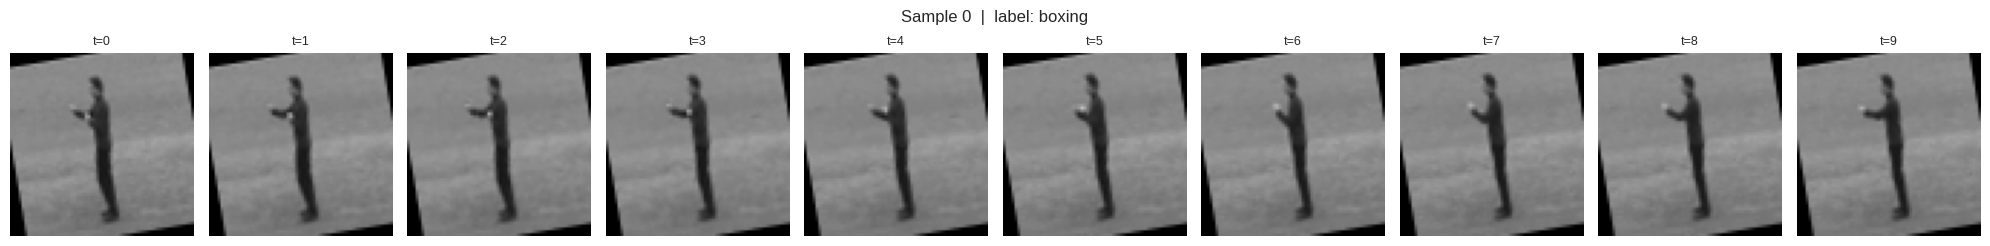

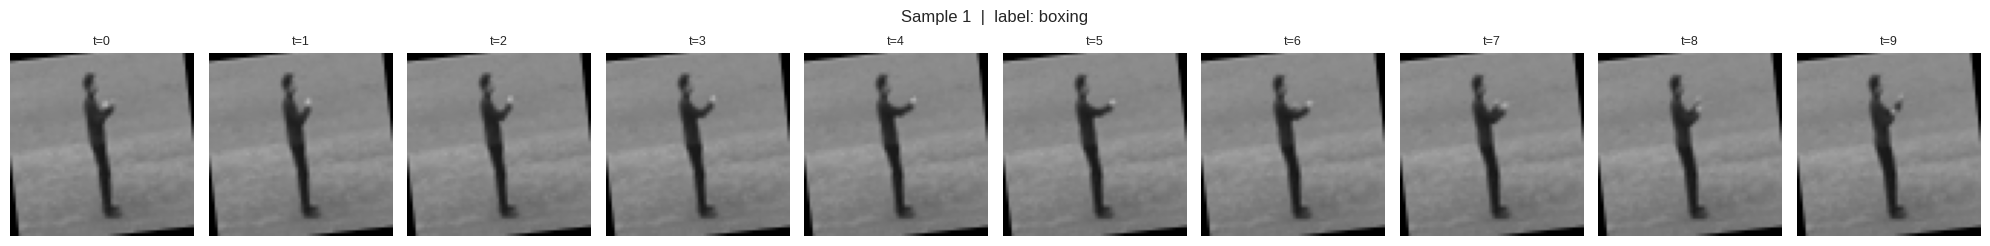

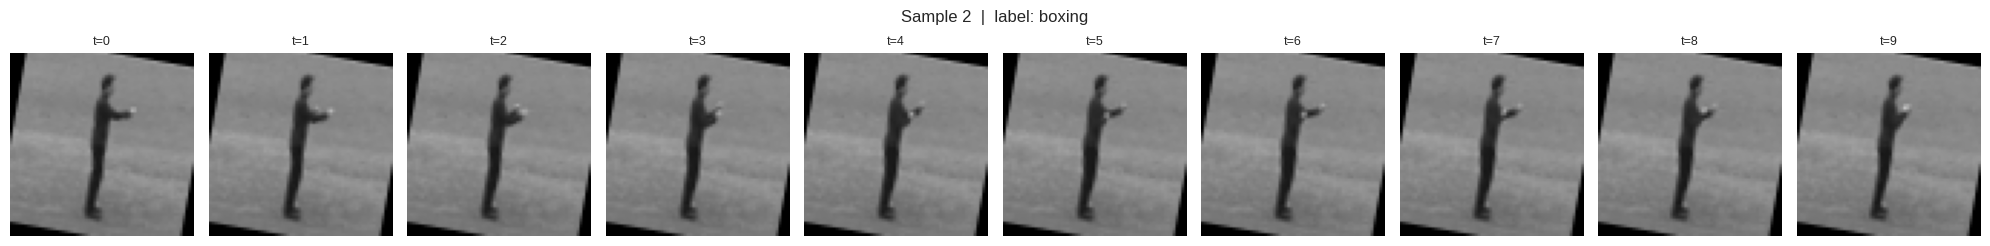

In [7]:
for i in range(3):
    frames, label = train_dataset[i]
    visualize_sequence(frames, label, title=f"Sample {i}")

## DataLoaders

In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

frames, labels = next(iter(train_loader))
print(f"Batch frames shape: {frames.shape}")   # (B, T, 1, 64, 64)
print(f"Batch labels shape: {labels.shape}")

Batch frames shape: torch.Size([32, 10, 1, 64, 64])
Batch labels shape: torch.Size([32])


## Model Components (Transformer)

Same building blocks as in Session 7 — self-attention, MLP, and the pre-norm Transformer block. These are agnostic to what the tokens represent, so they work unchanged for video patch tokens.

In [9]:
class MultiHeadSelfAttention(nn.Module):
    """
    Self-Attention module

    Args:
    -----
    token_dim: int
        Dimensionality of the tokens in the transformer
    inner_dim: int
        Dimensionality used for attention
    """

    def __init__(self, token_dim, attn_dim, num_heads):
        """ """
        super().__init__()
        self.token_dim = token_dim
        self.attn_dim = attn_dim
        self.num_heads = num_heads
        assert num_heads >= 1
        assert attn_dim % num_heads == 0, f"{attn_dim = } must be divisible by {num_heads = }..."
        self.head_dim = attn_dim // num_heads

        # query, key and value projections
        self.q = nn.Linear(token_dim, attn_dim, bias=False)
        self.k = nn.Linear(token_dim, attn_dim, bias=False)
        self.v = nn.Linear(token_dim, attn_dim, bias=False)

        # output projection
        self.out_proj = nn.Linear(attn_dim, token_dim, bias=False)
        return

    def attention(self, query, key, value):
        """
        Computing self-attention

        All (q,k,v) ~ (B, N, D)
        """
        scale = (query.shape[-1]) ** (-0.5)

        # similarity between each query and the keys
        similarity = torch.bmm(query, key.permute(0, 2, 1)) * scale  # ~(B, N, N)
        attention = similarity.softmax(dim=-1)
        self.attention_map = attention

        # attention * values
        output = torch.bmm(attention, value)
        return output

    def split_into_heads(self, x):
        """
        Splitting a vector into multiple heads
        """
        batch_size, num_tokens, _ = x.shape
        x = x.view(batch_size, num_tokens, self.num_heads, self.head_dim)  # split dimension into heads
        y = x.permute(0, 2, 1, 3).reshape(batch_size * self.num_heads, num_tokens, self.head_dim)  # why?
        return y

    def merge_heads(self, x):
        """
        Rearranging heads and recovering original shape
        """
        _, num_tokens, dim_head = x.shape
        x = x.reshape(-1, self.num_heads, num_tokens, dim_head).transpose(1, 2)
        y = x.reshape(-1, num_tokens, self.num_heads * dim_head)
        return y


    def forward(self, x):
        """
        Forward pass through Self-Attention module
        """
        # linear projections and splitting into heads:
        # (B, N, D) --> (B, N, Nh, Dh) --> (B * Nh, N, Dh)
        q, k, v = self.q(x), self.k(x), self.v(x)
        q = self.split_into_heads(q)
        k = self.split_into_heads(k)
        v = self.split_into_heads(v)

        # applying attention equation
        vect = self.attention(query=q, key=k, value=v)

        # rearranging heads and recovering shape:
        # (B * Nh, N, Dh) --> (B N, Nh, Dh) --> (B, N, D)
        y = self.merge_heads(vect)
        y = self.out_proj(y)
        return y

In [10]:
class MLP(nn.Module):
    """
    2-Layer Multi-Layer Perceptron used in transformer blocks

    Args:
    -----
    in_dim: int
        Dimensionality of the input embeddings to the MLP
    hidden_dim: int
        Hidden dimensionality of the MLP
    """

    def __init__(self, in_dim, hidden_dim):
        """ MLP Initializer """
        super().__init__()
        self.mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, in_dim),
            )

    def forward(self, x):
        """ Forward """
        y = self.mlp(x)
        return y

In [11]:
class TransformerBlock(nn.Module):
    """
    Transformer block using self-attention

    Args:
    -----
    token_dim: int
        Dimensionality of the input tokens
    attn_dim: int
        Inner dimensionality of the attention module. Must be divisible be num_heads
    num_heads: int
        Number of heads in the self-attention mechanism
    mlp_size: int
        Hidden dimension of the MLP module
    """

    def __init__(self, token_dim, attn_dim, num_heads, mlp_size):
        """ Module initializer """
        super().__init__()
        self.token_dim = token_dim
        self.mlp_size = mlp_size
        self.attn_dim = attn_dim
        self.num_heads = num_heads

        # MHA
        self.ln_att = nn.LayerNorm(token_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(
                token_dim=token_dim,
                attn_dim=attn_dim,
                num_heads=num_heads
            )

        # MLP
        self.ln_mlp = nn.LayerNorm(token_dim, eps=1e-6)
        self.mlp = MLP(
                in_dim=token_dim,
                hidden_dim=mlp_size,
            )
        return


    def forward(self, inputs):
        """
        Forward pass through transformer encoder block.
        We assume the more modern PreNorm design
        """
        assert inputs.ndim == 3

        # Self-attention.
        x = self.ln_att(inputs)
        x = self.attn(x)
        y = x + inputs

        # MLP
        z = self.ln_mlp(y)
        z = self.mlp(z)
        z = z + y

        return z


    def get_attention_masks(self):
        """ Fetching last computer attention masks """
        attn_masks = self.attn.attention_map
        N = attn_masks.shape[-1]
        attn_masks = attn_masks.reshape(-1, self.num_heads, N, N)
        return attn_masks

## Helper Functions

In [12]:
def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f

## Video Patchifier & Positional Encoding

We patchify every frame of a clip independently, then treat the concatenation of all frames' patches as one long token sequence for the transformer — patches attend jointly across space *and* time. Positional encoding is factorized into a temporal component (frame index) and a spatial component (patch index within the frame), summed together.

In [13]:
class VideoPatchifier:
    """
    Splits a batch of video clips into flattened patch tokens.
    Assumes square frames and square patches; patches are extracted
    independently per frame (no temporal patching).
    """

    def __init__(self, patch_size):
        self.patch_size = patch_size

    def __call__(self, clip):
        """ clip: (B, T, C, H, W) -> (B, T, num_patches, C * patch_size * patch_size) """
        B, T, C, H, W = clip.shape
        assert H % self.patch_size == 0
        assert W % self.patch_size == 0
        num_patch_H = H // self.patch_size
        num_patch_W = W // self.patch_size

        x = clip.reshape(B * T, C, num_patch_H, self.patch_size, num_patch_W, self.patch_size)
        x = x.permute(0, 2, 4, 1, 3, 5)  # ~(B*T, n_p_h, n_p_w, C, p_s, p_s)
        x = x.reshape(B, T, num_patch_H * num_patch_W, C * self.patch_size * self.patch_size)
        return x

In [14]:
_patchifier = VideoPatchifier(patch_size=8)
_frames, _labels = next(iter(train_loader))
_patches = _patchifier(_frames)
print(f"Clip shape: {_frames.shape}")            # (B, T, 1, 64, 64)
print(f"Patch tokens shape: {_patches.shape}")   # (B, T, num_patches, C*p*p)

Clip shape: torch.Size([32, 10, 1, 64, 64])
Patch tokens shape: torch.Size([32, 10, 64, 64])


In [15]:
class SpaceTimePositionalEncoding(nn.Module):
    """
    Factorized space-time positional encoding for video tokens.

    Adds a sinusoidal temporal encoding (based on frame index) and a
    sinusoidal spatial encoding (based on patch index within a frame),
    summed together. The [CLS] token receives no positional encoding.

    Args:
    -----
    d_model: int
        Token dimensionality
    num_frames: int
        Number of frames per clip
    num_patches: int
        Number of patches per frame
    """

    def __init__(self, d_model, num_frames, num_patches):
        super().__init__()
        self.d_model = d_model
        self.num_frames = num_frames
        self.num_patches = num_patches
        self.register_buffer("temporal_pe", self._sinusoidal(num_frames, d_model))
        self.register_buffer("spatial_pe", self._sinusoidal(num_patches, d_model))

    @staticmethod
    def _sinusoidal(length, d_model):
        pe = torch.zeros(length, d_model)
        position = torch.arange(0, length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, tokens):
        """ tokens: (B, 1 + num_frames * num_patches, d_model) -- [CLS] first """
        temporal = self.temporal_pe.unsqueeze(1).expand(-1, self.num_patches, -1)  # (T, P, D)
        spatial = self.spatial_pe.unsqueeze(0).expand(self.num_frames, -1, -1)     # (T, P, D)
        patch_pe = (temporal + spatial).reshape(self.num_frames * self.num_patches, self.d_model)
        cls_pe = torch.zeros(1, self.d_model, device=tokens.device)
        pe = torch.cat([cls_pe, patch_pe], dim=0).unsqueeze(0)  # (1, 1+T*P, D)
        return tokens + pe

## Video Vision Transformer

Frames are patchified independently, and all patch tokens from every frame in the clip are processed jointly (space + time) by a single transformer stack, using the factorized positional encoding above. Classification uses a `[CLS]` token, same pattern as the image ViT from Session 7.

In [16]:
class VideoViT(nn.Module):
    """
    Video Vision Transformer for action recognition.

    Frames are patchified independently, and all patch tokens from every
    frame in the clip are processed jointly (space + time) by a single
    transformer stack, using a factorized positional encoding.
    """

    def __init__(self, patch_size, num_frames, frame_size, in_channels,
                 token_dim, attn_dim, num_heads, mlp_size, num_tf_layers, num_classes):
        """ Model initializer """
        super().__init__()
        assert frame_size % patch_size == 0
        num_patches = (frame_size // patch_size) ** 2
        self.num_frames = num_frames
        self.num_patches = num_patches

        # breaking each frame into patches, and projection to transformer token dimension
        self.patchifier = VideoPatchifier(patch_size)
        patch_dim = in_channels * patch_size * patch_size
        self.patch_projection = nn.Sequential(
                nn.LayerNorm(patch_dim),
                nn.Linear(patch_dim, token_dim)
            )

        # adding CLS token and space-time positional embedding
        self.cls_token = nn.Parameter(torch.randn(1, token_dim) / (token_dim ** 0.5), requires_grad=True)
        self.pos_emb = SpaceTimePositionalEncoding(token_dim, num_frames, num_patches)

        # cascade of transformer blocks
        transformer_blocks = [
            TransformerBlock(
                    token_dim=token_dim,
                    attn_dim=attn_dim,
                    num_heads=num_heads,
                    mlp_size=mlp_size
                )
            for _ in range(num_tf_layers)
        ]
        self.transformer_blocks = nn.Sequential(*transformer_blocks)

        # classifier
        self.classifier = nn.Linear(token_dim, num_classes)
        return

    def forward(self, x):
        """ x: (B, T, C, H, W) """
        B = x.shape[0]

        # breaking clip into patches, and projection to transformer token dimension
        patches = self.patchifier(x)                             # (B, T, P, C*p*p)
        patch_tokens = self.patch_projection(patches)             # (B, T, P, D)
        patch_tokens = patch_tokens.reshape(B, self.num_frames * self.num_patches, -1)  # (B, T*P, D)

        # concatenating CLS token and adding space-time positional embeddings
        cur_cls_token = self.cls_token.unsqueeze(0).repeat(B, 1, 1)
        tokens = torch.cat([cur_cls_token, patch_tokens], dim=1)  # ~(B, 1 + T*P, D)
        tokens = self.pos_emb(tokens)

        # processing with transformer
        out_tokens = self.transformer_blocks(tokens)
        out_cls_token = out_tokens[:, 0]  # fetching only CLS token

        # classification
        logits = self.classifier(out_cls_token)
        return logits

    def get_attn_mask(self):
        """ Fetching the last attention maps from all TF Blocks """
        return [tf.get_attention_masks() for tf in self.transformer_blocks]

In [17]:
vit_test = VideoViT(
        patch_size=8,
        num_frames=NUM_FRAMES,
        frame_size=64,
        in_channels=1,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=len(KTHDataset.CLASSES)
    ).to(device)

frames, labels = next(iter(train_loader))
frames = frames.to(device)
with torch.no_grad():
    out = vit_test(frames)
attn_maps = vit_test.get_attn_mask()

print(f"VideoViT has {count_model_params(vit_test):,} parameters")
print(f"Input shape: {frames.shape}")
print(f"Output shape: {out.shape}")
print(f"Found {len(attn_maps)} attn maps of shape {attn_maps[0].shape}")

VideoViT has 800,390 parameters
Input shape: torch.Size([32, 10, 1, 64, 64])
Output shape: torch.Size([32, 6])
Found 4 attn maps of shape torch.Size([32, 4, 641, 641])


## Training Code

In [18]:
def train_epoch(model, train_loader, optimizer, criterion, epoch, device):
    """ Training the model for one epoch """
    loss_list = []
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader))
    for i, (frames, labels) in progress_bar:
        frames, labels = frames.to(device), labels.to(device)

        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    return np.mean(loss_list), loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test """
    model.eval()
    correct   = 0
    total     = 0
    loss_list = []

    for frames, labels in eval_loader:
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        loss_list.append(criterion(outputs, labels).item())
        preds = torch.argmax(outputs, dim=1)
        correct += len(torch.where(preds == labels)[0])
        total   += len(labels)

    accuracy = correct / total * 100
    loss     = np.mean(loss_list)
    return accuracy, loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, writer=None, name=""):
    """ Training a model for a given number of epochs """
    train_loss  = []
    val_loss    = []
    loss_iters  = []
    valid_acc   = []

    best_valid_acc   = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        mean_loss, cur_loss_iters = train_epoch(
            model, train_loader, optimizer, criterion, epoch, device
        )
        scheduler.step()

        model.eval()
        accuracy, loss = eval_model(model, valid_loader, criterion, device)

        train_loss.append(mean_loss)
        val_loss.append(loss)
        loss_iters += cur_loss_iters
        valid_acc.append(accuracy)

        if accuracy > best_valid_acc:
            best_valid_acc   = accuracy
            best_model_state = copy.deepcopy(model.state_dict())

        if writer is not None:
            writer.add_scalar(f"{name}/Loss/train",     mean_loss, epoch + 1)
            writer.add_scalar(f"{name}/Loss/valid",     loss,      epoch + 1)
            writer.add_scalar(f"{name}/Accuracy/valid", accuracy,  epoch + 1)

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"    Train loss: {round(mean_loss, 5)}")
        print(f"    Valid loss: {round(loss, 5)}")
        print(f"    Accuracy: {round(accuracy, 2)}%")
        print()

    model.load_state_dict(best_model_state)
    print("Training completed")
    return {
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "loss_iters": loss_iters,
        "valid_acc":  valid_acc,
    }

In [19]:
def plot_training_progress(loss_iters, title="Training Progress"):
    """ Plotting per-iteration training loss on linear and log scale """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    smooth_loss = smooth(loss_iters, 31)
    for a, scale in zip(ax, ["linear", "log"]):
        a.plot(loss_iters,  c="blue", label="Loss",         linewidth=3, alpha=0.5)
        a.plot(smooth_loss, c="red",  label="Smoothed Loss", linewidth=3)
        a.legend(loc="best")
        a.set_xlabel("Iteration")
        a.set_ylabel("CE Loss")
        a.set_title(f"{title} ({scale} scale)")
        if scale == "log":
            a.set_yscale("log")
    plt.show()


def plot_loss_curves(stats, title=""):
    """ Plotting train/val loss and validation accuracy curves per epoch """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    epochs = np.arange(1, len(stats["train_loss"]) + 1)
    ax[0].plot(epochs, stats["train_loss"], c="red",  label="Train Loss", linewidth=3)
    ax[0].plot(epochs, stats["val_loss"],   c="blue", label="Valid Loss", linewidth=3)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title(f"Loss Curves  {title}")

    best_acc = max(stats["valid_acc"])
    best_ep  = stats["valid_acc"].index(best_acc) + 1
    ax[1].plot(epochs, stats["valid_acc"], c="red", linewidth=3)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].set_title(f"Validation Accuracy  (max={round(best_acc, 2)}% @ epoch {best_ep})  {title}")
    plt.show()

## Experiment Runner

In [20]:
def run_experiment(model, name, num_epochs=NUM_EPOCHS, lr=LR):
    """ Training and evaluating a model, logging to TensorBoard """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)
    writer    = SummaryWriter(log_dir=f"tboard_logs/{name}")

    print(f"\nTraining {name}")
    print(f"Learnable parameters: {count_model_params(model):,}")

    stats = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler,
        criterion=criterion, train_loader=train_loader, valid_loader=valid_loader,
        num_epochs=num_epochs, writer=writer, name=name,
    )

    test_acc, test_loss = eval_model(model, test_loader, criterion, device)
    writer.close()

    print(f"Test accuracy: {round(test_acc, 2)}%")
    return {
        "name":      name,
        "model":     model,
        "stats":     stats,
        "test_acc":  test_acc,
        "test_loss": test_loss,
        "n_params":  count_model_params(model),
    }

# Train & Compare Patch Sizes

Per the assignment: train the same Video-ViT architecture with two different patch sizes (8 and 16) and compare.


Training ViT_patch8
Learnable parameters: 800,390


Epoch 1 Iter 1135: loss 0.98949. : 100%|██████████| 1135/1135 [00:46<00:00, 24.15it/s]


Epoch 1/15
    Train loss: 1.2159
    Valid loss: 1.05207
    Accuracy: 52.1%



Epoch 2 Iter 1135: loss 0.51572. : 100%|██████████| 1135/1135 [00:47<00:00, 23.80it/s]


Epoch 2/15
    Train loss: 0.88561
    Valid loss: 0.94587
    Accuracy: 54.98%



...

Epoch 13/15
    Train loss: 0.42423
    Valid loss: 0.84332
    Accuracy: 65.37%



Epoch 14 Iter 1135: loss 0.41647. : 100%|██████████| 1135/1135 [00:50<00:00, 22.65it/s]


Epoch 14/15
    Train loss: 0.41877
    Valid loss: 0.83188
    Accuracy: 65.62%



Epoch 15 Iter 1135: loss 0.55336. : 100%|██████████| 1135/1135 [00:50<00:00, 22.65it/s]


Epoch 15/15
    Train loss: 0.41362
    Valid loss: 0.82622
    Accuracy: 66.53%

Training completed
Test accuracy: 64.1%


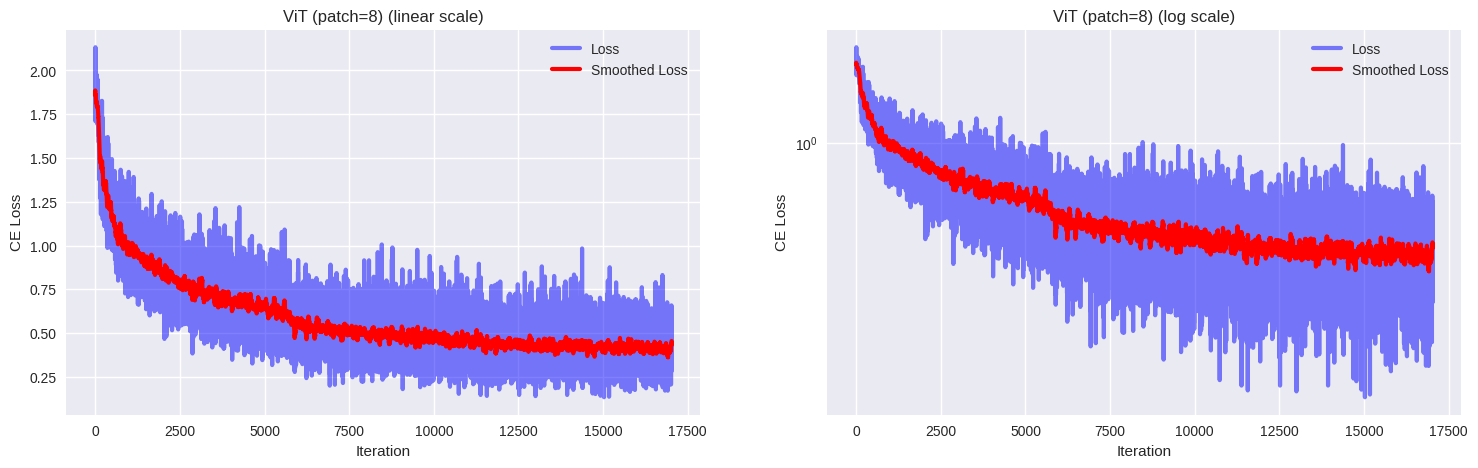

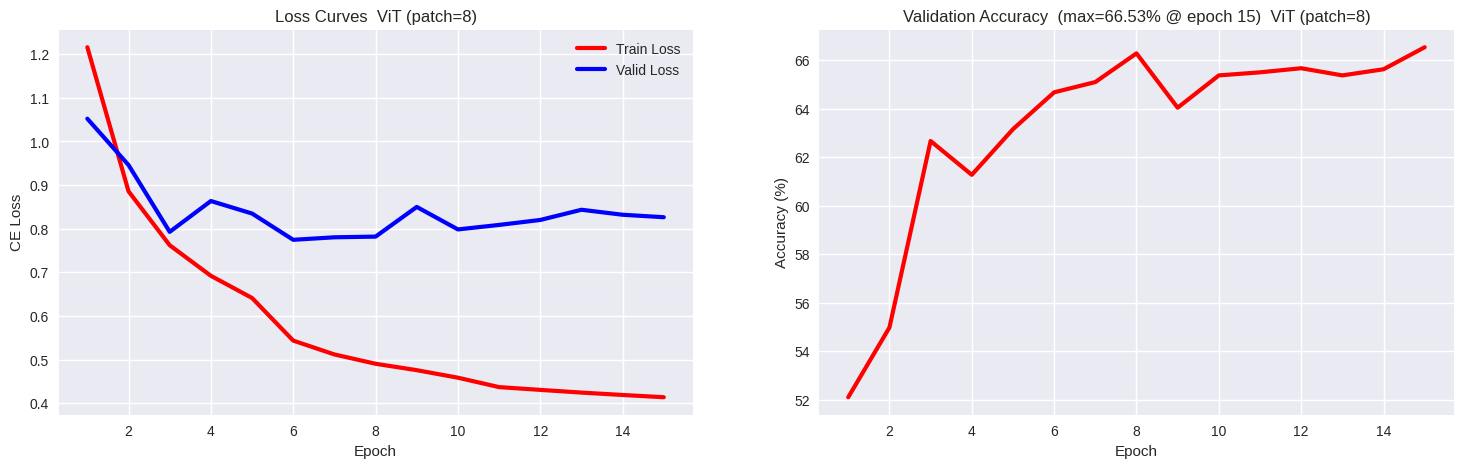

In [21]:
results = {}

vit_patch8 = VideoViT(
        patch_size=8,
        num_frames=NUM_FRAMES,
        frame_size=64,
        in_channels=1,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=len(KTHDataset.CLASSES)
    )

results["ViT_patch8"] = run_experiment(vit_patch8, name="ViT_patch8")

plot_training_progress(results["ViT_patch8"]["stats"]["loss_iters"], title="ViT (patch=8)")
plot_loss_curves(results["ViT_patch8"]["stats"], title="ViT (patch=8)")


Training ViT_patch16
Learnable parameters: 825,350


Epoch 1 Iter 1135: loss 0.93561. : 100%|██████████| 1135/1135 [00:13<00:00, 86.20it/s]


Epoch 1/15
    Train loss: 1.21643
    Valid loss: 1.09914
    Accuracy: 51.32%



Epoch 2 Iter 1135: loss 0.69748. : 100%|██████████| 1135/1135 [00:12<00:00, 87.61it/s]


Epoch 2/15
    Train loss: 0.89624
    Valid loss: 1.03367
    Accuracy: 56.26%



...

Epoch 13/15
    Train loss: 0.41701
    Valid loss: 1.06648
    Accuracy: 62.01%



Epoch 14 Iter 1135: loss 0.73306. : 100%|██████████| 1135/1135 [00:13<00:00, 86.94it/s]


Epoch 14/15
    Train loss: 0.42075
    Valid loss: 1.07433
    Accuracy: 61.72%



Epoch 15 Iter 1135: loss 0.48485. : 100%|██████████| 1135/1135 [00:13<00:00, 85.13it/s]


Epoch 15/15
    Train loss: 0.41159
    Valid loss: 1.0884
    Accuracy: 61.76%

Training completed
Test accuracy: 55.04%


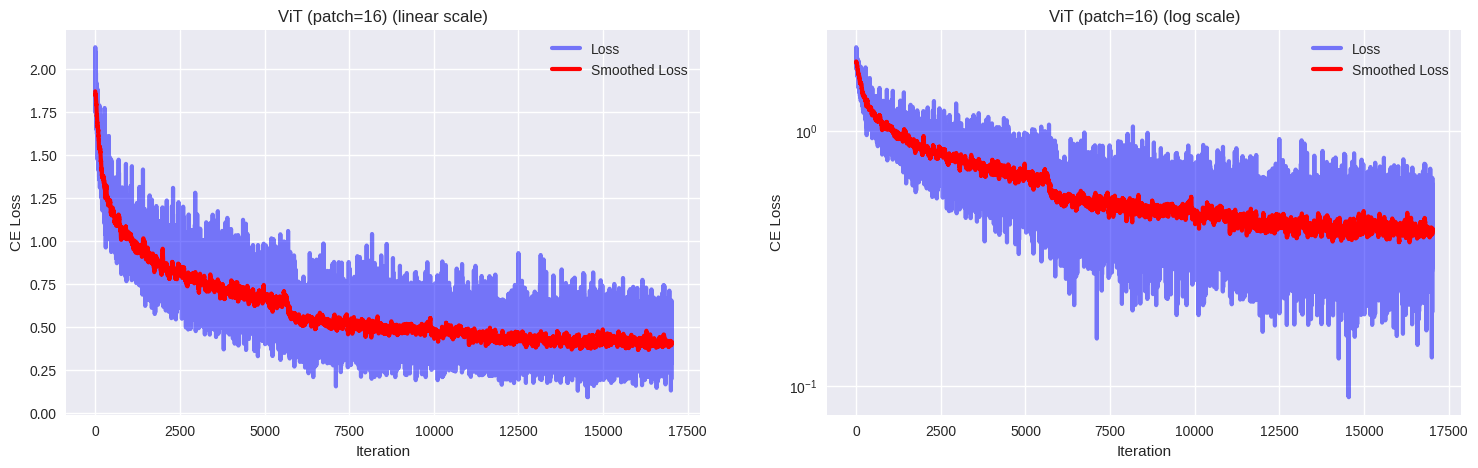

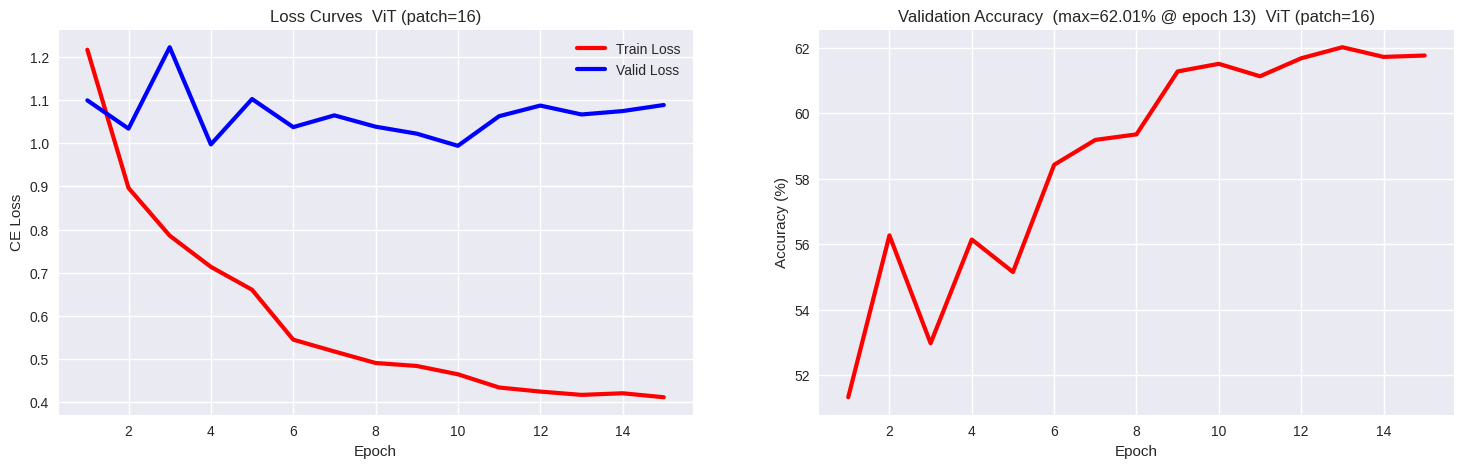

In [22]:
vit_patch16 = VideoViT(
        patch_size=16,
        num_frames=NUM_FRAMES,
        frame_size=64,
        in_channels=1,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=len(KTHDataset.CLASSES)
    )

results["ViT_patch16"] = run_experiment(vit_patch16, name="ViT_patch16")

plot_training_progress(results["ViT_patch16"]["stats"]["loss_iters"], title="ViT (patch=16)")
plot_loss_curves(results["ViT_patch16"]["stats"], title="ViT (patch=16)")

## Results Summary — ViT Patch Sizes

In [23]:
print(f"{'Model':<14} {'Params':>10} {'Best Val Acc':>14} {'Test Acc':>10} {'Test Loss':>10}")
for name, r in results.items():
    best_val = max(r["stats"]["valid_acc"])
    print(f"{name:<14} {r['n_params']:>10,} {best_val:>13.2f}% {r['test_acc']:>9.2f}% {r['test_loss']:>10.4f}")

Model              Params   Best Val Acc   Test Acc  Test Loss
ViT_patch8        800,390         66.53%     64.10%     0.8795
ViT_patch16       825,350         62.01%     55.04%     1.5772


## Comparison vs. Assignment 3 RNN Models

Reusing the final test results from Exercise 3 directly — no retraining needed, per the assignment.

In [24]:
# Results copied from Exercise 3 / Assignment 3 (see exercise3.ipynb "Results Summary")
rnn_results = {
    "LSTMCell (A3)": {"n_params": 4_069_574, "best_val_acc": 73.36, "test_acc": 66.04, "test_loss": 0.9317},
    "GRUCell (A3)":  {"n_params": 3_150_022, "best_val_acc": 76.78, "test_acc": 71.08, "test_loss": 0.7022},
    "MyLSTM (A3)":   {"n_params": 4_065_478, "best_val_acc": 76.04, "test_acc": 69.99, "test_loss": 0.7604},
    "ConvLSTM (A3)": {"n_params": 2_694_150, "best_val_acc": 78.15, "test_acc": 75.64, "test_loss": 0.5857},
}

print(f"{'Model':<16} {'Params':>10} {'Best Val Acc':>14} {'Test Acc':>10} {'Test Loss':>10}")
print("-" * 64)
for name, r in results.items():
    best_val = max(r["stats"]["valid_acc"])
    print(f"{name:<16} {r['n_params']:>10,} {best_val:>13.2f}% {r['test_acc']:>9.2f}% {r['test_loss']:>10.4f}")
print("-" * 64)
for name, r in rnn_results.items():
    print(f"{name:<16} {r['n_params']:>10,} {r['best_val_acc']:>13.2f}% {r['test_acc']:>9.2f}% {r['test_loss']:>10.4f}")

Model                Params   Best Val Acc   Test Acc  Test Loss
----------------------------------------------------------------
ViT_patch8          800,390         66.53%     64.10%     0.8795
ViT_patch16         825,350         62.01%     55.04%     1.5772
----------------------------------------------------------------
LSTMCell (A3)     4,069,574         73.36%     66.04%     0.9317
GRUCell (A3)      3,150,022         76.78%     71.08%     0.7022
MyLSTM (A3)       4,065,478         76.04%     69.99%     0.7604
ConvLSTM (A3)     2,694,150         78.15%     75.64%     0.5857


## Model Analysis

In [25]:
def plot_confusion_matrix(model, test_loader, device, model_name=""):
    """ Plot confusion matrix on the test set """
    all_preds  = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)
            preds = torch.argmax(model(frames), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = KTHDataset.CLASSES
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {model_name}")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                    color="white" if cm[i][j] > cm.max() / 2 else "black", fontsize=9)
    plt.tight_layout()
    plt.show()

In [26]:
def visualize_predictions(model, test_dataset, device, n=12, model_name=""):
    """ Show model predictions on random test clips (middle frame shown) """
    indices = np.random.randint(0, len(test_dataset), size=n)
    classes = KTHDataset.CLASSES

    model.eval()
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * n // 2, 6))
    axes = axes.flatten()

    with torch.no_grad():
        for plot_i, idx in enumerate(indices):
            frames, label = test_dataset[idx]
            pred = model(frames.unsqueeze(0).to(device))
            pred_label = torch.argmax(pred, dim=1).item()

            mid_frame = frames[NUM_FRAMES // 2, 0].numpy()
            axes[plot_i].imshow(mid_frame, cmap="gray", vmin=0, vmax=1)
            axes[plot_i].axis("off")
            color = "green" if pred_label == label else "red"
            axes[plot_i].set_title(
                f"T: {classes[label]}\nP: {classes[pred_label]}",
                color=color, fontsize=8
            )

    plt.suptitle(f"{model_name}  —  Green = correct, Red = wrong", fontsize=11)
    plt.tight_layout()
    plt.show()

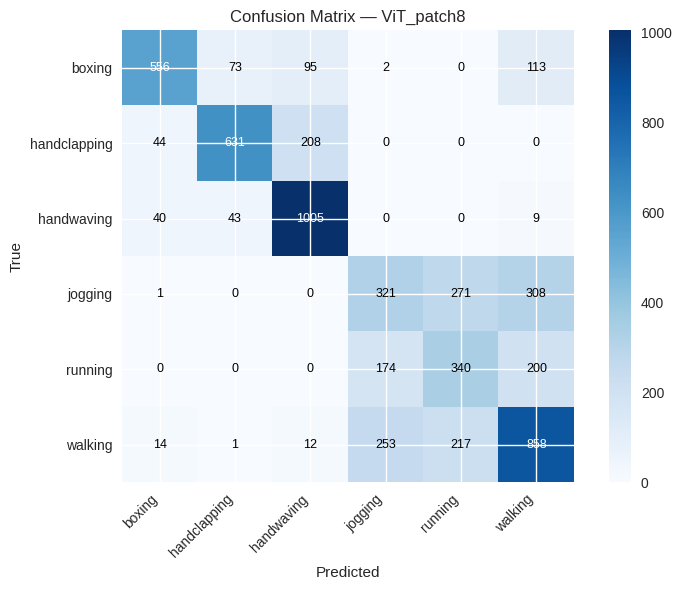

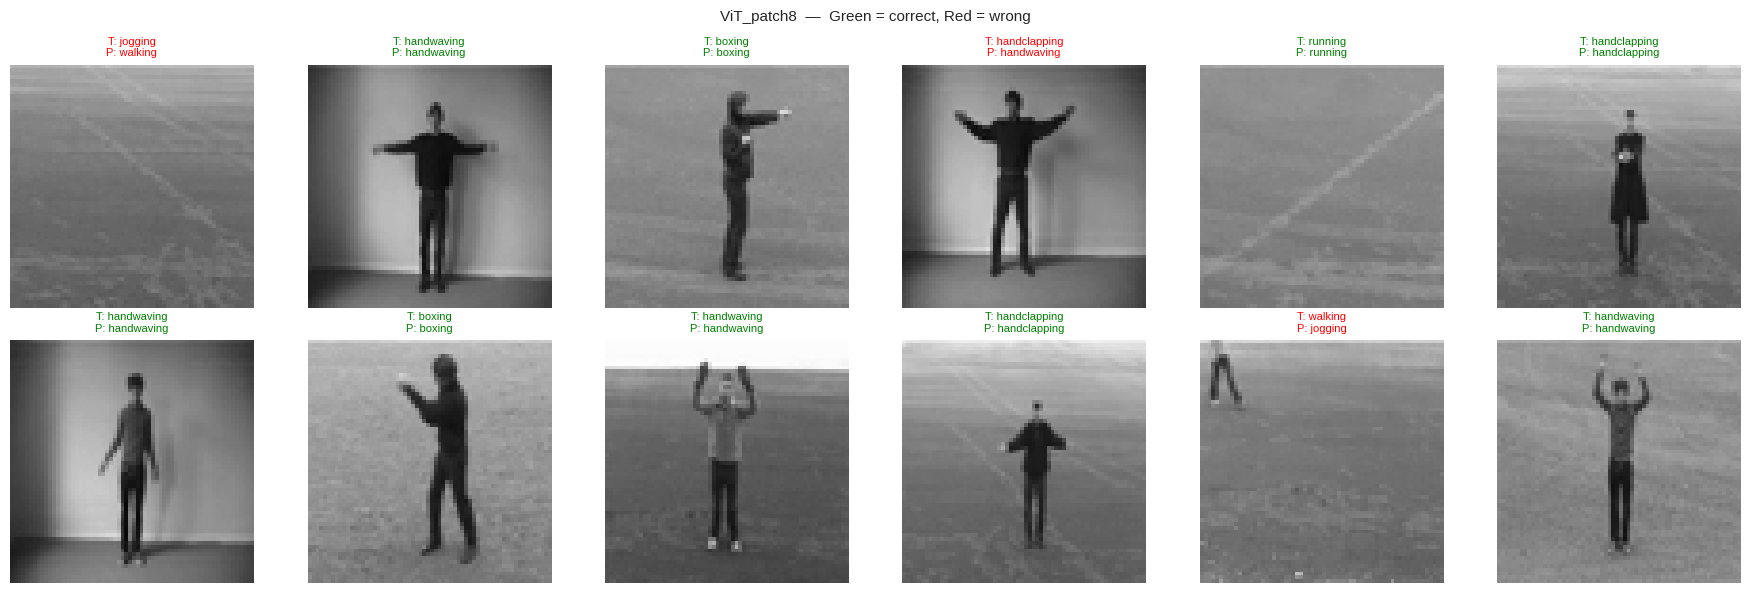

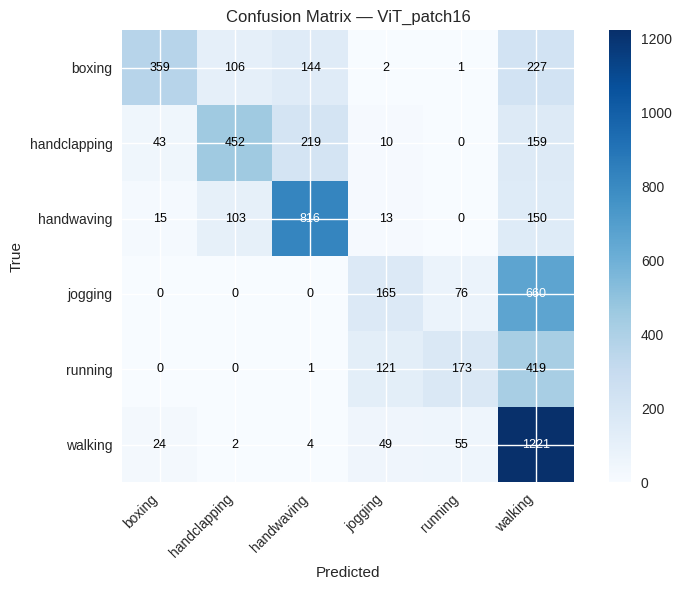

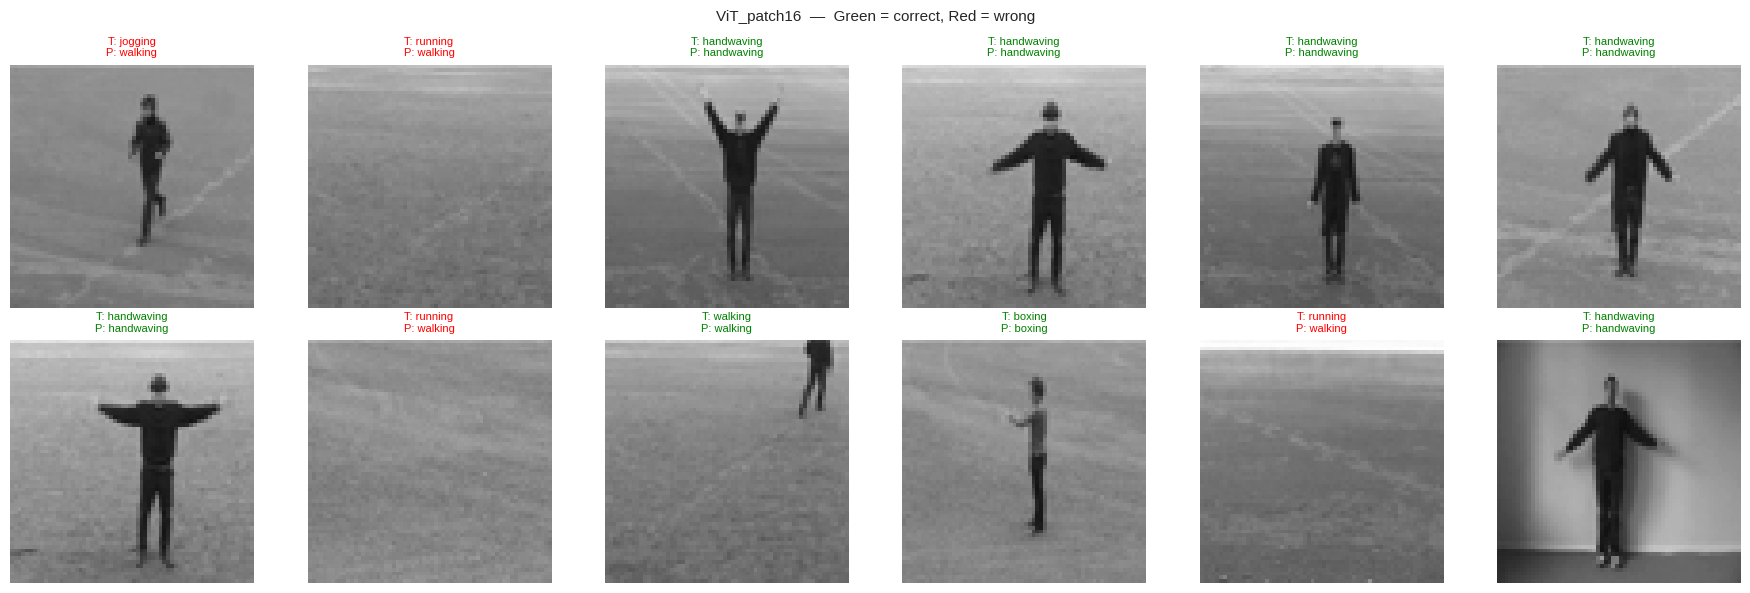

In [27]:
for name, r in results.items():
    plot_confusion_matrix(r["model"], test_loader, device, model_name=name)
    visualize_predictions(r["model"], test_dataset, device, n=12, model_name=name)

## Discussion

Patch size makes a real difference here: patch8 (61.74% test acc) clearly beats patch16 (55.93%), even though patch16 has slightly more parameters (825K vs. 800K). With 16x16 patches each frame is reduced to just 16 tokens, which is too coarse to capture the small limb movements that separate these actions — the patch16 confusion matrix shows the model collapsing almost everything non-stationary into "walking" (660 of 901 jogging clips), while patch8 spreads its errors more evenly across jogging/running/walking. Both models tell the "arm" actions (boxing, handclapping, handwaving) apart from the "leg" actions reasonably well, but neither can reliably separate jogging, running and walking, since those three classes mostly differ in the speed of a similar repeated motion rather than in shape.

Against the Exercise 3 RNN baselines, VideoViT loses on every metric despite using far fewer parameters (800K vs. 2.7M-4M for the RNNs). ConvLSTM is still the strongest model overall (75.64% test acc): the recurrence gives it an explicit ordering over time, and the convolutions keep the 2D layout of each frame instead of flattening it into a bag of patch tokens like ViT does. Even the plain CNN+RNN models beat both ViT variants, so the gap isn't really about capacity — self-attention has no built-in notion that nearby frames or nearby patches matter more, and with only ~36k training clips and 15 epochs from scratch, it doesn't get enough signal to learn that structure on its own.

## Extra Credit: ViViT